In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import os

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import xgboost as xgb

print("All libraries imported successfully.")
print("XGBoost version:", xgb.__version__)

All libraries imported successfully.
XGBoost version: 3.4.1


In [ ]:
users = pd.read_csv("/content/users.csv")
flights = pd.read_csv("/content/flights.csv")
hotels = pd.read_csv("/content/hotels.csv")

print("Users shape:", users.shape)
print("Flights shape:", flights.shape)
print("Hotels shape:", hotels.shape)

Users shape: (1340, 5)
Flights shape: (271888, 10)
Hotels shape: (40552, 8)


In [ ]:
print("USER COLUMNS:")
print(users.columns.tolist())

print("\nFLIGHT COLUMNS:")
print(flights.columns.tolist())

print("\nHOTEL COLUMNS:")
print(hotels.columns.tolist())

USER COLUMNS:
['code', 'company', 'name', 'gender', 'age']

FLIGHT COLUMNS:
['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time', 'distance', 'agency', 'date']

HOTEL COLUMNS:
['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']


In [ ]:
print("Users shape:", users.shape)

print("\nFirst 5 rows:")
display(users.head())

print("\nData types:")
print(users.dtypes)

print("\nMissing values:")
print(users.isnull().sum())

Users shape: (1340, 5)

First 5 rows:


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44



Data types:
code        int64
company    object
name       object
gender     object
age         int64
dtype: object

Missing values:
code       0
company    0
name       0
gender     0
age        0
dtype: int64


In [ ]:
print("Gender distribution:")
print(users["gender"].value_counts())

print("\nGender percentage:")
print(
    users["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Gender distribution:
gender
male      452
female    448
none      440
Name: count, dtype: int64

Gender percentage:
gender
male      33.73
female    33.43
none      32.84
Name: proportion, dtype: float64


In [ ]:
print("Flights shape:", flights.shape)

print("\nFirst 5 rows:")
display(flights.head())

print("\nData types:")
print(flights.dtypes)

print("\nMissing values:")
print(flights.isnull().sum())

Flights shape: (271888, 10)

First 5 rows:


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019



Data types:
travelCode      int64
userCode        int64
from           object
to             object
flightType     object
price         float64
time          float64
distance      float64
agency         object
date           object
dtype: object

Missing values:
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64


In [ ]:
flight_user_features = (
    flights
    .groupby("userCode")
    .agg(
        flight_count=("travelCode", "count"),
        total_flight_spend=("price", "sum"),
        average_flight_price=("price", "mean"),
        average_flight_distance=("distance", "mean"),
        total_flight_distance=("distance", "sum"),
        average_flight_time=("time", "mean"),
        unique_destinations=("to", "nunique"),
        unique_origins=("from", "nunique"),
        unique_flight_types=("flightType", "nunique"),
        unique_agencies=("agency", "nunique")
    )
    .reset_index()
)

print(
    "Flight behavioral dataset shape:",
    flight_user_features.shape
)

display(
    flight_user_features.head()
)

Flight behavioral dataset shape: (1335, 11)


,userCode,flight_count,total_flight_spend,average_flight_price,average_flight_distance,total_flight_distance,average_flight_time,unique_destinations,unique_origins,unique_flight_types,unique_agencies
0,0,178,176053.77,989.066124,527.233596,93847.58,1.370337,9,9,3,3
1,1,12,9826.78,818.898333,508.648333,6103.78,1.321667,6,6,3,3
2,2,262,237613.52,906.921832,513.671374,134581.90,1.335191,9,9,3,3
3,3,398,372891.73,936.913894,506.074372,201417.60,1.315176,9,9,3,3
4,4,398,381042.58,957.393417,517.955477,206146.28,1.345930,9,9,3,3


In [ ]:
print("Hotels shape:", hotels.shape)

print("\nFirst 5 rows:")
display(hotels.head())

print("\nData types:")
print(hotels.dtypes)

print("\nMissing values:")
print(hotels.isnull().sum())

Hotels shape: (40552, 8)

First 5 rows:


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019



Data types:
travelCode      int64
userCode        int64
name           object
place          object
days            int64
price         float64
total         float64
date           object
dtype: object

Missing values:
travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64


In [ ]:
hotel_user_features = (
    hotels
    .groupby("userCode")
    .agg(
        hotel_booking_count=("travelCode", "count"),
        total_hotel_spend=("total", "sum"),
        average_hotel_spend=("total", "mean"),
        average_hotel_price=("price", "mean"),
        average_stay_days=("days", "mean"),
        total_stay_days=("days", "sum"),
        unique_hotels=("name", "nunique"),
        unique_hotel_locations=("place", "nunique")
    )
    .reset_index()
)

print(
    "Hotel behavioral dataset shape:",
    hotel_user_features.shape
)

display(
    hotel_user_features.head()
)


Hotel behavioral dataset shape: (1310, 9)


,userCode,hotel_booking_count,total_hotel_spend,average_hotel_spend,average_hotel_price,average_stay_days,total_stay_days,unique_hotels,unique_hotel_locations
0,0,27,16014.92,593.145185,225.741481,2.629630,71,9,9
1,1,2,386.72,193.360000,193.360000,1.000000,2,2,2
2,2,36,20088.12,558.003333,210.050000,2.694444,97,9,9
3,3,60,29974.11,499.568500,217.058500,2.300000,138,9,9
4,4,56,31657.70,565.316071,214.947679,2.571429,144,9,9


In [ ]:
user_ml_data = users.merge(
    flight_user_features,
    left_on="code",
    right_on="userCode",
    how="left"
)

user_ml_data = user_ml_data.merge(
    hotel_user_features,
    left_on="code",
    right_on="userCode",
    how="left",
    suffixes=("", "_hotel")
)

print(
    "Merged dataset shape:",
    user_ml_data.shape
)

display(
    user_ml_data.head()
)

Merged dataset shape: (1340, 25)


,code,company,name,gender,age,userCode,flight_count,total_flight_spend,average_flight_price,average_flight_distance,...,unique_agencies,userCode_hotel,hotel_booking_count,total_hotel_spend,average_hotel_spend,average_hotel_price,average_stay_days,total_stay_days,unique_hotels,unique_hotel_locations
0,0,4You,Roy Braun,male,21,0.0,178.0,176053.77,989.066124,527.233596,...,3.0,0.0,27.0,16014.92,593.145185,225.741481,2.629630,71.0,9.0,9.0
1,1,4You,Joseph Holsten,male,37,1.0,12.0,9826.78,818.898333,508.648333,...,3.0,1.0,2.0,386.72,193.360000,193.360000,1.000000,2.0,2.0,2.0
2,2,4You,Wilma Mcinnis,female,48,2.0,262.0,237613.52,906.921832,513.671374,...,3.0,2.0,36.0,20088.12,558.003333,210.050000,2.694444,97.0,9.0,9.0
3,3,4You,Paula Daniel,female,23,3.0,398.0,372891.73,936.913894,506.074372,...,3.0,3.0,60.0,29974.11,499.568500,217.058500,2.300000,138.0,9.0,9.0
4,4,4You,Patricia Carson,female,44,4.0,398.0,381042.58,957.393417,517.955477,...,3.0,4.0,56.0,31657.70,565.316071,214.947679,2.571429,144.0,9.0,9.0


In [ ]:
user_ml_data = user_ml_data.drop(
    columns=[
        "userCode",
        "userCode_hotel"
    ],
    errors="ignore"
)

print("Dataset shape after removing ID columns:")
print(user_ml_data.shape)

print("\nColumns:")
print(user_ml_data.columns.tolist())

Dataset shape after removing ID columns:
(1340, 23)

Columns:
['code', 'company', 'name', 'gender', 'age', 'flight_count', 'total_flight_spend', 'average_flight_price', 'average_flight_distance', 'total_flight_distance', 'average_flight_time', 'unique_destinations', 'unique_origins', 'unique_flight_types', 'unique_agencies', 'hotel_booking_count', 'total_hotel_spend', 'average_hotel_spend', 'average_hotel_price', 'average_stay_days', 'total_stay_days', 'unique_hotels', 'unique_hotel_locations']


In [ ]:
user_ml_data = user_ml_data.drop(
    columns=[
        "userCode",
        "userCode_hotel"
    ],
    errors="ignore"
)

print("Dataset shape after removing ID columns:")
print(user_ml_data.shape)

print("\nColumns:")
print(user_ml_data.columns.tolist())

Dataset shape after removing ID columns:
(1340, 23)

Columns:
['code', 'company', 'name', 'gender', 'age', 'flight_count', 'total_flight_spend', 'average_flight_price', 'average_flight_distance', 'total_flight_distance', 'average_flight_time', 'unique_destinations', 'unique_origins', 'unique_flight_types', 'unique_agencies', 'hotel_booking_count', 'total_hotel_spend', 'average_hotel_spend', 'average_hotel_price', 'average_stay_days', 'total_stay_days', 'unique_hotels', 'unique_hotel_locations']


In [ ]:
behavior_columns = [
    "flight_count",
    "total_flight_spend",
    "average_flight_price",
    "average_flight_distance",
    "total_flight_distance",
    "average_flight_time",
    "unique_destinations",
    "unique_origins",
    "unique_flight_types",
    "unique_agencies",
    "hotel_booking_count",
    "total_hotel_spend",
    "average_hotel_spend",
    "average_hotel_price",
    "average_stay_days",
    "total_stay_days",
    "unique_hotels",
    "unique_hotel_locations"
]

print("Missing values in behavioral features:")

display(
    user_ml_data[behavior_columns]
    .isnull()
    .sum()
)

Missing values in behavioral features:


,0
flight_count,5
total_flight_spend,5
average_flight_price,5
average_flight_distance,5
total_flight_distance,5
average_flight_time,5
unique_destinations,5
unique_origins,5
unique_flight_types,5
unique_agencies,5


In [ ]:
user_ml_data[behavior_columns] = (
    user_ml_data[behavior_columns]
    .fillna(0)
)

print("Missing values after filling:")

display(
    user_ml_data[behavior_columns]
    .isnull()
    .sum()
)

Missing values after filling:


,0
flight_count,0
total_flight_spend,0
average_flight_price,0
average_flight_distance,0
total_flight_distance,0
average_flight_time,0
unique_destinations,0
unique_origins,0
unique_flight_types,0
unique_agencies,0


In [ ]:
print("Dataset shape:", user_ml_data.shape)

print("\nNumber of unique users:")
print(user_ml_data["code"].nunique())

print("\nDuplicate rows:")
print(user_ml_data.duplicated().sum())

print("\nDuplicate user codes:")
print(user_ml_data["code"].duplicated().sum())

Dataset shape: (1340, 23)

Number of unique users:
1340

Duplicate rows:
0

Duplicate user codes:
0


In [ ]:
numeric_features_check = [
    "age",
    "flight_count",
    "total_flight_spend",
    "average_flight_price",
    "average_flight_distance",
    "total_flight_distance",
    "average_flight_time",
    "unique_destinations",
    "unique_origins",
    "unique_flight_types",
    "unique_agencies",
    "hotel_booking_count",
    "total_hotel_spend",
    "average_hotel_spend",
    "average_hotel_price",
    "average_stay_days",
    "total_stay_days",
    "unique_hotels",
    "unique_hotel_locations"
]

numeric_summary = user_ml_data[
    numeric_features_check
].describe().T

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
age,1340.0,42.742537,12.869779,21.0,32.000000,42.000000,54.000000,65.00
flight_count,1340.0,202.901493,118.193519,0.0,100.000000,199.000000,310.000000,400.00
total_flight_spend,1340.0,194252.822493,115100.547733,0.0,95826.825000,186947.745000,295389.630000,442901.02
average_flight_price,1340.0,952.800962,110.135463,0.0,892.925897,933.189993,1038.027188,1654.54
average_flight_distance,1340.0,544.587839,103.790882,0.0,469.464339,507.812154,662.447859,937.77
total_flight_distance,1340.0,110978.094493,68672.013324,0.0,52723.105000,105368.580000,161336.285000,271864.20
average_flight_time,1340.0,1.414998,0.269803,0.0,1.219776,1.319635,1.721566,2.44
unique_destinations,1340.0,8.657463,1.242686,0.0,9.000000,9.000000,9.000000,9.00
unique_origins,1340.0,8.657463,1.242686,0.0,9.000000,9.000000,9.000000,9.00
unique_flight_types,1340.0,2.938806,0.335794,0.0,3.000000,3.000000,3.000000,3.00


In [ ]:
classification_features = [
    "company",
    "age",
    "flight_count",
    "total_flight_spend",
    "average_flight_price",
    "average_flight_distance",
    "total_flight_distance",
    "average_flight_time",
    "unique_destinations",
    "unique_origins",
    "unique_flight_types",
    "unique_agencies",
    "hotel_booking_count",
    "total_hotel_spend",
    "average_hotel_spend",
    "average_hotel_price",
    "average_stay_days",
    "total_stay_days",
    "unique_hotels",
    "unique_hotel_locations"
]

X = user_ml_data[classification_features].copy()

y = user_ml_data["gender"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.unique())

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (1340, 20)
Target shape: (1340,)

Target classes:
['male' 'female' 'none']

Feature columns:
['company', 'age', 'flight_count', 'total_flight_spend', 'average_flight_price', 'average_flight_distance', 'total_flight_distance', 'average_flight_time', 'unique_destinations', 'unique_origins', 'unique_flight_types', 'unique_agencies', 'hotel_booking_count', 'total_hotel_spend', 'average_hotel_spend', 'average_hotel_price', 'average_stay_days', 'total_stay_days', 'unique_hotels', 'unique_hotel_locations']


In [ ]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original → Encoded class mapping:")

for original, encoded in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(f"{original} → {encoded}")

print("\nEncoded target distribution:")
print(
    pd.Series(y_encoded).value_counts().sort_index()
)

Original → Encoded class mapping:
female → 0
male → 1
none → 2

Encoded target distribution:
0    448
1    452
2    440
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("\nTraining target distribution:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nTesting target distribution:")
print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)

Training features: (1072, 20)
Testing features : (268, 20)

Training target distribution:
0    358
1    362
2    352
Name: count, dtype: int64

Testing target distribution:
0    90
1    90
2    88
Name: count, dtype: int64


In [ ]:
categorical_features = [
    "company"
]

numeric_features = [
    "age",
    "flight_count",
    "total_flight_spend",
    "average_flight_price",
    "average_flight_distance",
    "total_flight_distance",
    "average_flight_time",
    "unique_destinations",
    "unique_origins",
    "unique_flight_types",
    "unique_agencies",
    "hotel_booking_count",
    "total_hotel_spend",
    "average_hotel_spend",
    "average_hotel_price",
    "average_stay_days",
    "total_stay_days",
    "unique_hotels",
    "unique_hotel_locations"
]

print("Categorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Categorical features:
['company']

Number of numerical features: 19
Number of categorical features: 1


In [ ]:
numeric_transformer = Pipeline(
    steps = [
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps = [
        (
            "onehot",
            OneHotEncoder(
                handle_unknown= "ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
baseline_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

baseline_classifier.fit(
    X_train,
    y_train
)

baseline_predictions = (
    baseline_classifier.predict(X_test)
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_result = {
    "Model": "Baseline",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1": baseline_f1
}

print("Baseline Results")
print("=" * 30)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

Baseline Results
Accuracy : 0.3358
Precision: 0.1128
Recall   : 0.3358
F1 Score : 0.1688


In [ ]:
logistic_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_classifier.fit(
    X_train,
    y_train
)

logistic_predictions = (
    logistic_classifier.predict(X_test)
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_probabilities = (
    logistic_classifier.predict_proba(X_test)
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities,
    multi_class="ovr",
    average="weighted"
)

logistic_result = {
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1": logistic_f1,
    "ROC-AUC": logistic_roc_auc
}

print("Logistic Regression Results")
print("=" * 35)
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")
print(f"ROC-AUC  : {logistic_roc_auc:.4f}")

Logistic Regression Results
Accuracy : 0.3358
Precision: 0.3369
Recall   : 0.3358
F1 Score : 0.3363
ROC-AUC  : 0.5063


In [ ]:
rf_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_classifier.fit(
    X_train,
    y_train
)

rf_predictions = (
    rf_classifier.predict(X_test)
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_probabilities = (
    rf_classifier.predict_proba(X_test)
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probabilities,
    multi_class="ovr",
    average="weighted"
)

rf_result = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1": rf_f1,
    "ROC-AUC": rf_roc_auc
}

print("Random Forest Results")
print("=" * 30)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
Accuracy : 0.3321
Precision: 0.3326
Recall   : 0.3321
F1 Score : 0.3317
ROC-AUC  : 0.5025


In [ ]:
gb_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gb_classifier.fit(
    X_train,
    y_train
)

gb_predictions = (
    gb_classifier.predict(X_test)
)

gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)

gb_precision = precision_score(
    y_test,
    gb_predictions,
    average="weighted",
    zero_division=0
)

gb_recall = recall_score(
    y_test,
    gb_predictions,
    average="weighted",
    zero_division=0
)

gb_f1 = f1_score(
    y_test,
    gb_predictions,
    average="weighted",
    zero_division=0
)

gb_probabilities = (
    gb_classifier.predict_proba(X_test)
)

gb_roc_auc = roc_auc_score(
    y_test,
    gb_probabilities,
    multi_class="ovr",
    average="weighted"
)

gb_result = {
    "Model": "Gradient Boosting",
    "Accuracy": gb_accuracy,
    "Precision": gb_precision,
    "Recall": gb_recall,
    "F1": gb_f1,
    "ROC-AUC": gb_roc_auc
}

print("Gradient Boosting Results")
print("=" * 35)
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")
print(f"ROC-AUC  : {gb_roc_auc:.4f}")

Gradient Boosting Results
Accuracy : 0.3321
Precision: 0.3317
Recall   : 0.3321
F1 Score : 0.3319
ROC-AUC  : 0.5060


In [ ]:
xgb_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            xgb.XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=3,
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_classifier.fit(
    X_train,
    y_train
)

print("XGBoost training completed successfully.")

XGBoost training completed successfully.


In [ ]:
xgb_predictions = xgb_classifier.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_probabilities = (
    xgb_classifier.predict_proba(X_test)
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_probabilities,
    multi_class="ovr",
    average="weighted"
)

xgb_result = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1": xgb_f1,
    "ROC-AUC": xgb_roc_auc
}

print("XGBoost Results")
print("=" * 30)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Results
Accuracy : 0.3060
Precision: 0.3053
Recall   : 0.3060
F1 Score : 0.3049
ROC-AUC  : 0.4946


In [ ]:
classification_results = pd.DataFrame([
    baseline_result,
    logistic_result,
    rf_result,
    gb_result,
    xgb_result
])

classification_results = (
    classification_results
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    classification_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.3358,0.3369,0.3358,0.3363,0.5063
1,Gradient Boosting,0.3321,0.3317,0.3321,0.3319,0.5060
2,Random Forest,0.3321,0.3326,0.3321,0.3317,0.5025
3,XGBoost,0.3060,0.3053,0.3060,0.3049,0.4946
4,Baseline,0.3358,0.1128,0.3358,0.1688,NaN


In [ ]:
print("Actual test distribution:")
print(
    pd.Series(
        label_encoder.inverse_transform(
            y_test.astype(int)
        )
    ).value_counts()
)

print("\nLogistic Regression predictions:")
print(
    pd.Series(
        label_encoder.inverse_transform(
            logistic_predictions.astype(int)
        )
    ).value_counts()
)

print("\nRandom Forest predictions:")
print(
    pd.Series(
        label_encoder.inverse_transform(
            rf_predictions.astype(int)
        )
    ).value_counts()
)

print("\nGradient Boosting predictions:")
print(
    pd.Series(
        label_encoder.inverse_transform(
            gb_predictions.astype(int)
        )
    ).value_counts()
)

print("\nXGBoost predictions:")
print(
    pd.Series(
        label_encoder.inverse_transform(
            xgb_predictions.astype(int)
        )
    ).value_counts()
)

Actual test distribution:
male      90
female    90
none      88
Name: count, dtype: int64

Logistic Regression predictions:
female    93
male      89
none      86
Name: count, dtype: int64

Random Forest predictions:
male      96
none      93
female    79
Name: count, dtype: int64

Gradient Boosting predictions:
female    91
none      89
male      88
Name: count, dtype: int64

XGBoost predictions:
none      100
male       86
female     82
Name: count, dtype: int64


In [ ]:
gender_numeric_summary = (
    user_ml_data
    .groupby("gender")[numeric_features]
    .mean()
    .T
)

display(
    gender_numeric_summary.round(2)
)

gender,female,male,none
age,43.18,42.70,42.34
flight_count,204.42,201.88,202.41
total_flight_spend,195544.66,193995.81,193201.52
average_flight_price,951.77,958.23,948.28
average_flight_distance,545.02,549.31,539.29
total_flight_distance,111879.61,110985.48,110052.60
average_flight_time,1.42,1.43,1.40
unique_destinations,8.68,8.67,8.63
unique_origins,8.68,8.67,8.63
unique_flight_types,2.94,2.95,2.92


In [ ]:
from scipy.stats import f_oneway

anova_results = []

for feature in numeric_features:

    female_values = user_ml_data.loc[
        user_ml_data["gender"] == "female",
        feature
    ]

    male_values = user_ml_data.loc[
        user_ml_data["gender"] == "male",
        feature
    ]

    none_values = user_ml_data.loc[
        user_ml_data["gender"] == "none",
        feature
    ]

    f_stat, p_value = f_oneway(
        female_values,
        male_values,
        none_values
    )

    anova_results.append({
        "Feature": feature,
        "F_statistic": f_stat,
        "p_value": p_value
    })

anova_results = pd.DataFrame(
    anova_results
)

anova_results = (
    anova_results
    .sort_values(
        "p_value"
    )
    .reset_index(drop=True)
)

display(
    anova_results.round(6)
)

,Feature,F_statistic,p_value
0,average_stay_days,3.957266,0.019340
1,average_hotel_spend,1.356818,0.257833
2,unique_agencies,1.250699,0.286639
3,average_flight_time,1.045618,0.351762
4,average_flight_distance,1.044990,0.351983
5,average_flight_price,0.938607,0.391430
6,average_hotel_price,0.712267,0.490717
7,unique_hotels,0.573612,0.563625
8,unique_hotel_locations,0.573612,0.563625
9,unique_flight_types,0.560638,0.570979


In [ ]:
company_gender_table = pd.crosstab(
    user_ml_data["company"],
    user_ml_data["gender"],
    normalize="index"
) * 100

print(
    "Gender percentage within each company:"
)

display(
    company_gender_table.round(2)
)

Gender percentage within each company:


gender,female,male,none
company,,,
4You,33.33,30.46,36.20
Acme Factory,32.57,35.63,31.80
Monsters CYA,32.82,31.28,35.90
Umbrella LTDA,35.57,36.08,28.35
Wonka Company,33.33,37.97,28.69


In [ ]:
print("Company counts:")

display(
    user_ml_data["company"]
    .value_counts()
)

print("\nCompany × Gender counts:")

display(
    pd.crosstab(
        user_ml_data["company"],
        user_ml_data["gender"]
    )
)

Company counts:


,count
company,
4You,453
Acme Factory,261
Wonka Company,237
Monsters CYA,195
Umbrella LTDA,194



Company × Gender counts:


gender,female,male,none
company,,,
4You,151,138,164
Acme Factory,85,93,83
Monsters CYA,64,61,70
Umbrella LTDA,69,70,55
Wonka Company,79,90,68


In [ ]:
from scipy.stats import chi2_contingency

company_gender_counts = pd.crosstab(
    user_ml_data["company"],
    user_ml_data["gender"]
)

chi2, p_value, degrees_freedom, expected = (
    chi2_contingency(company_gender_counts)
)

print("Chi-Square Test")
print("=" * 30)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom : {degrees_freedom}")
print(f"P-value             : {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Significant association between company and gender.")
else:
    print("\nResult: No statistically significant association between company and gender.")

Chi-Square Test
Chi-square statistic: 8.6243
Degrees of freedom : 8
P-value             : 0.374978

Result: No statistically significant association between company and gender.


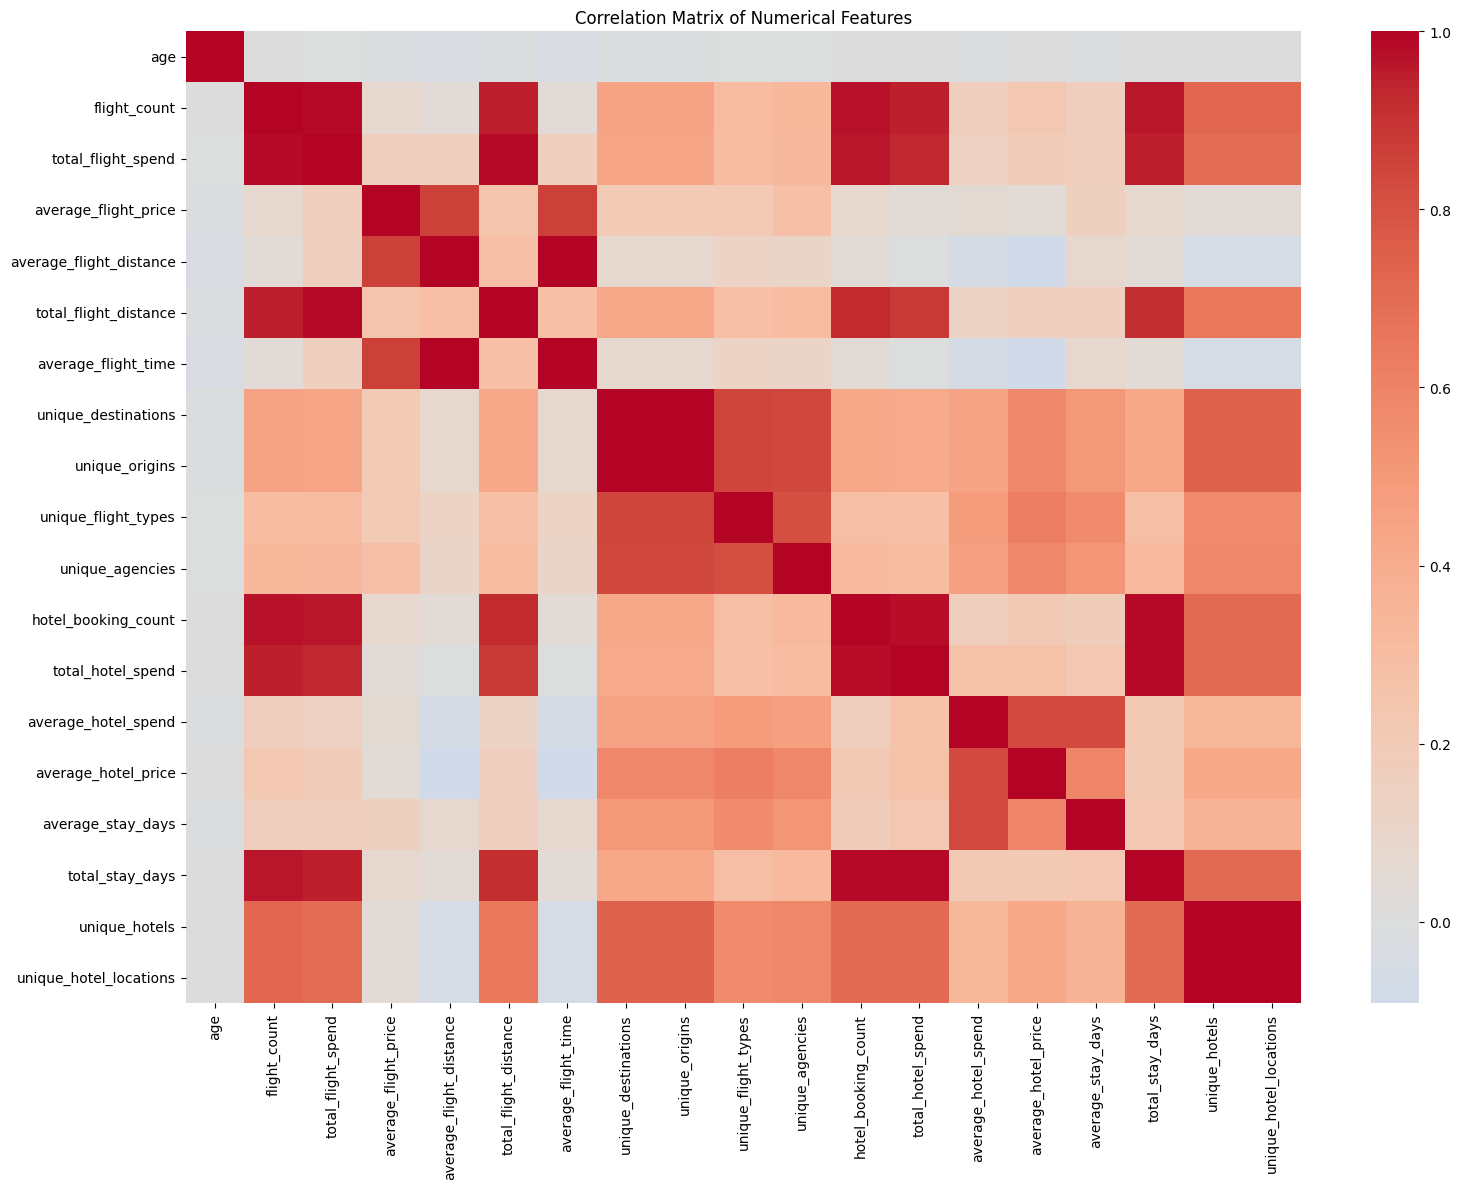

In [ ]:
correlation_matrix = (
    user_ml_data[numeric_features]
    .corr()
)

plt.figure(
    figsize=(16, 12)
)

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Numerical Features"
)

plt.tight_layout()

plt.show()

In [ ]:
corr_matrix = user_ml_data[
    numeric_features
].corr()

corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

corr_pairs["Abs_Correlation"] = (
    corr_pairs["Correlation"]
    .abs()
)

corr_pairs = (
    corr_pairs
    .sort_values(
        "Abs_Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    corr_pairs.head(15).round(4)
)

,Feature_1,Feature_2,Correlation,Abs_Correlation
0,unique_destinations,unique_origins,1.0000,1.0000
1,unique_hotels,unique_hotel_locations,1.0000,1.0000
2,average_flight_distance,average_flight_time,1.0000,1.0000
3,hotel_booking_count,total_stay_days,0.9904,0.9904
4,total_hotel_spend,total_stay_days,0.9896,0.9896
5,flight_count,total_flight_spend,0.9877,0.9877
6,total_flight_spend,total_flight_distance,0.9845,0.9845
7,hotel_booking_count,total_hotel_spend,0.9803,0.9803
8,flight_count,hotel_booking_count,0.9688,0.9688
9,total_flight_spend,hotel_booking_count,0.9591,0.9591


In [ ]:
redundant_features = [
    "unique_origins",
    "unique_hotel_locations",
    "average_flight_time"
]

classification_features_reduced = [
    feature
    for feature in classification_features
    if feature not in redundant_features
]

print("Removed features:")
print(redundant_features)

print("\nRemaining features:")
print(classification_features_reduced)

print(
    "\nNumber of remaining features:",
    len(classification_features_reduced)
)

Removed features:
['unique_origins', 'unique_hotel_locations', 'average_flight_time']

Remaining features:
['company', 'age', 'flight_count', 'total_flight_spend', 'average_flight_price', 'average_flight_distance', 'total_flight_distance', 'unique_destinations', 'unique_flight_types', 'unique_agencies', 'hotel_booking_count', 'total_hotel_spend', 'average_hotel_spend', 'average_hotel_price', 'average_stay_days', 'total_stay_days', 'unique_hotels']

Number of remaining features: 17


In [ ]:

# -----------------------------------------
# 1. Create reduced feature matrix
# -----------------------------------------

X_reduced = user_ml_data[
    classification_features_reduced
].copy()

print("Reduced feature matrix shape:", X_reduced.shape)


# -----------------------------------------
# 2. Define feature types
# -----------------------------------------

categorical_features_reduced = [
    "company"
]

numeric_features_reduced = [
    feature
    for feature in classification_features_reduced
    if feature not in categorical_features_reduced
]

print("\nNumerical features:", len(numeric_features_reduced))
print("Categorical features:", len(categorical_features_reduced))


# -----------------------------------------
# 3. Create preprocessing pipeline
# -----------------------------------------

numeric_transformer_reduced = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer_reduced = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor_reduced = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_reduced,
            numeric_features_reduced
        ),
        (
            "cat",
            categorical_transformer_reduced,
            categorical_features_reduced
        )
    ]
)

print("\nPreprocessing pipeline created successfully.")

Reduced feature matrix shape: (1340, 17)

Numerical features: 16
Categorical features: 1

Preprocessing pipeline created successfully.


In [ ]:

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training features:", X_train_reduced.shape)
print("Testing features :", X_test_reduced.shape)

print("\nTraining target distribution:")
print(
    pd.Series(y_train_reduced)
    .value_counts()
    .sort_index()
)

print("\nTesting target distribution:")
print(
    pd.Series(y_test_reduced)
    .value_counts()
    .sort_index()
)

Training features: (1072, 17)
Testing features : (268, 17)

Training target distribution:
0    358
1    362
2    352
Name: count, dtype: int64

Testing target distribution:
0    90
1    90
2    88
Name: count, dtype: int64


In [ ]:
# Cell 38 — Logistic Regression (Reduced Features)

logistic_reduced = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_reduced
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_reduced.fit(
    X_train_reduced,
    y_train_reduced
)

logistic_reduced_predictions = (
    logistic_reduced.predict(X_test_reduced)
)

logistic_reduced_accuracy = accuracy_score(
    y_test_reduced,
    logistic_reduced_predictions
)

logistic_reduced_precision = precision_score(
    y_test_reduced,
    logistic_reduced_predictions,
    average="weighted",
    zero_division=0
)

logistic_reduced_recall = recall_score(
    y_test_reduced,
    logistic_reduced_predictions,
    average="weighted",
    zero_division=0
)

logistic_reduced_f1 = f1_score(
    y_test_reduced,
    logistic_reduced_predictions,
    average="weighted",
    zero_division=0
)

logistic_reduced_probabilities = (
    logistic_reduced.predict_proba(X_test_reduced)
)

logistic_reduced_roc_auc = roc_auc_score(
    y_test_reduced,
    logistic_reduced_probabilities,
    multi_class="ovr",
    average="weighted"
)

logistic_reduced_result = {
    "Model": "Logistic Regression (Reduced)",
    "Accuracy": logistic_reduced_accuracy,
    "Precision": logistic_reduced_precision,
    "Recall": logistic_reduced_recall,
    "F1": logistic_reduced_f1,
    "ROC-AUC": logistic_reduced_roc_auc
}

print("Logistic Regression — Reduced Features")
print("=" * 45)
print(f"Accuracy : {logistic_reduced_accuracy:.4f}")
print(f"Precision: {logistic_reduced_precision:.4f}")
print(f"Recall   : {logistic_reduced_recall:.4f}")
print(f"F1 Score : {logistic_reduced_f1:.4f}")
print(f"ROC-AUC  : {logistic_reduced_roc_auc:.4f}")

Logistic Regression — Reduced Features
Accuracy : 0.3358
Precision: 0.3369
Recall   : 0.3358
F1 Score : 0.3363
ROC-AUC  : 0.5059


In [ ]:
rf_reduced = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_reduced
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_reduced.fit(
    X_train_reduced,
    y_train_reduced
)

rf_reduced_predictions = (
    rf_reduced.predict(X_test_reduced)
)

rf_reduced_accuracy = accuracy_score(
    y_test_reduced,
    rf_reduced_predictions
)

rf_reduced_precision = precision_score(
    y_test_reduced,
    rf_reduced_predictions,
    average="weighted",
    zero_division=0
)

rf_reduced_recall = recall_score(
    y_test_reduced,
    rf_reduced_predictions,
    average="weighted",
    zero_division=0
)

rf_reduced_f1 = f1_score(
    y_test_reduced,
    rf_reduced_predictions,
    average="weighted",
    zero_division=0
)

rf_reduced_probabilities = (
    rf_reduced.predict_proba(X_test_reduced)
)

rf_reduced_roc_auc = roc_auc_score(
    y_test_reduced,
    rf_reduced_probabilities,
    multi_class="ovr",
    average="weighted"
)

rf_reduced_result = {
    "Model": "Random Forest (Reduced)",
    "Accuracy": rf_reduced_accuracy,
    "Precision": rf_reduced_precision,
    "Recall": rf_reduced_recall,
    "F1": rf_reduced_f1,
    "ROC-AUC": rf_reduced_roc_auc
}

print("Random Forest — Reduced Features")
print("=" * 40)
print(f"Accuracy : {rf_reduced_accuracy:.4f}")
print(f"Precision: {rf_reduced_precision:.4f}")
print(f"Recall   : {rf_reduced_recall:.4f}")
print(f"F1 Score : {rf_reduced_f1:.4f}")
print(f"ROC-AUC  : {rf_reduced_roc_auc:.4f}")

Random Forest — Reduced Features
Accuracy : 0.3172
Precision: 0.3167
Recall   : 0.3172
F1 Score : 0.3168
ROC-AUC  : 0.5101


In [ ]:
gb_reduced = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_reduced
        ),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gb_reduced.fit(
    X_train_reduced,
    y_train_reduced
)

gb_reduced_predictions = (
    gb_reduced.predict(X_test_reduced)
)

gb_reduced_accuracy = accuracy_score(
    y_test_reduced,
    gb_reduced_predictions
)

gb_reduced_precision = precision_score(
    y_test_reduced,
    gb_reduced_predictions,
    average="weighted",
    zero_division=0
)

gb_reduced_recall = recall_score(
    y_test_reduced,
    gb_reduced_predictions,
    average="weighted",
    zero_division=0
)

gb_reduced_f1 = f1_score(
    y_test_reduced,
    gb_reduced_predictions,
    average="weighted",
    zero_division=0
)

gb_reduced_probabilities = (
    gb_reduced.predict_proba(X_test_reduced)
)

gb_reduced_roc_auc = roc_auc_score(
    y_test_reduced,
    gb_reduced_probabilities,
    multi_class="ovr",
    average="weighted"
)

gb_reduced_result = {
    "Model": "Gradient Boosting (Reduced)",
    "Accuracy": gb_reduced_accuracy,
    "Precision": gb_reduced_precision,
    "Recall": gb_reduced_recall,
    "F1": gb_reduced_f1,
    "ROC-AUC": gb_reduced_roc_auc
}

print("Gradient Boosting — Reduced Features")
print("=" * 45)
print(f"Accuracy : {gb_reduced_accuracy:.4f}")
print(f"Precision: {gb_reduced_precision:.4f}")
print(f"Recall   : {gb_reduced_recall:.4f}")
print(f"F1 Score : {gb_reduced_f1:.4f}")
print(f"ROC-AUC  : {gb_reduced_roc_auc:.4f}")


Gradient Boosting — Reduced Features
Accuracy : 0.3433
Precision: 0.3437
Recall   : 0.3433
F1 Score : 0.3434
ROC-AUC  : 0.4995


In [ ]:
# Cell 41 — XGBoost (Reduced Features)

xgb_reduced = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_reduced
        ),
        (
            "model",
            xgb.XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=3,
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_reduced.fit(
    X_train_reduced,
    y_train_reduced
)

print("Reduced-feature XGBoost training completed.")

Reduced-feature XGBoost training completed.


In [ ]:

xgb_reduced_predictions = (
    xgb_reduced.predict(X_test_reduced)
)

xgb_reduced_accuracy = accuracy_score(
    y_test_reduced,
    xgb_reduced_predictions
)

xgb_reduced_precision = precision_score(
    y_test_reduced,
    xgb_reduced_predictions,
    average="weighted",
    zero_division=0
)

xgb_reduced_recall = recall_score(
    y_test_reduced,
    xgb_reduced_predictions,
    average="weighted",
    zero_division=0
)

xgb_reduced_f1 = f1_score(
    y_test_reduced,
    xgb_reduced_predictions,
    average="weighted",
    zero_division=0
)

xgb_reduced_probabilities = (
    xgb_reduced.predict_proba(X_test_reduced)
)

xgb_reduced_roc_auc = roc_auc_score(
    y_test_reduced,
    xgb_reduced_probabilities,
    multi_class="ovr",
    average="weighted"
)

xgb_reduced_result = {
    "Model": "XGBoost (Reduced)",
    "Accuracy": xgb_reduced_accuracy,
    "Precision": xgb_reduced_precision,
    "Recall": xgb_reduced_recall,
    "F1": xgb_reduced_f1,
    "ROC-AUC": xgb_reduced_roc_auc
}

print("XGBoost — Reduced Features")
print("=" * 40)
print(f"Accuracy : {xgb_reduced_accuracy:.4f}")
print(f"Precision: {xgb_reduced_precision:.4f}")
print(f"Recall   : {xgb_reduced_recall:.4f}")
print(f"F1 Score : {xgb_reduced_f1:.4f}")
print(f"ROC-AUC  : {xgb_reduced_roc_auc:.4f}")

XGBoost — Reduced Features
Accuracy : 0.3134
Precision: 0.3117
Recall   : 0.3134
F1 Score : 0.3120
ROC-AUC  : 0.4948


In [ ]:
reduced_results = pd.DataFrame([
    logistic_reduced_result,
    rf_reduced_result,
    gb_reduced_result,
    xgb_reduced_result
])

reduced_results = (
    reduced_results
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Final Reduced-Feature Model Comparison")
print("=" * 50)

display(
    reduced_results.round(4)
)

Final Reduced-Feature Model Comparison


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting (Reduced),0.3433,0.3437,0.3433,0.3434,0.4995
1,Logistic Regression (Reduced),0.3358,0.3369,0.3358,0.3363,0.5059
2,Random Forest (Reduced),0.3172,0.3167,0.3172,0.3168,0.5101
3,XGBoost (Reduced),0.3134,0.3117,0.3134,0.3120,0.4948


In [ ]:

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    gb_reduced,
    X_test_reduced,
    y_test_reduced,
    scoring="accuracy",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test_reduced.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance.round(6)
)

,Feature,Importance_Mean,Importance_STD
0,total_flight_spend,0.029478,0.014204
1,total_stay_days,0.029104,0.009844
2,hotel_booking_count,0.020522,0.014475
3,average_stay_days,0.017164,0.023729
4,company,0.013433,0.008209
5,average_flight_distance,0.010821,0.011000
6,total_flight_distance,0.007836,0.019986
7,total_hotel_spend,0.007090,0.018007
8,average_flight_price,0.005597,0.022466
9,flight_count,0.003358,0.012085


In [ ]:

user_ml_data["total_travel_spend"] = (
    user_ml_data["total_flight_spend"]
    + user_ml_data["total_hotel_spend"]
)

user_ml_data["total_bookings"] = (
    user_ml_data["flight_count"]
    + user_ml_data["hotel_booking_count"]
)

behavior_comparison = (
    user_ml_data
    .groupby("gender")[
        [
            "total_travel_spend",
            "total_bookings",
            "total_flight_distance",
            "total_stay_days"
        ]
    ]
    .mean()
)

display(
    behavior_comparison.round(2)
)

,total_travel_spend,total_bookings,total_flight_distance,total_stay_days
gender,,,,
female,211910.64,234.98,111879.61,76.58
male,210145.76,231.93,110985.48,75.11
none,209368.44,232.58,110052.60,75.25


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    gb_reduced,
    X_reduced,
    y_encoded,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold Cross-Validation Results")
print("=" * 40)

print("Fold accuracies:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean CV accuracy:", round(cv_scores.mean(), 4))
print("Std CV accuracy :", round(cv_scores.std(), 4))

5-Fold Cross-Validation Results
Fold accuracies:
Fold 1: 0.3209
Fold 2: 0.3470
Fold 3: 0.3731
Fold 4: 0.3358
Fold 5: 0.2985

Mean CV accuracy: 0.3351
Std CV accuracy : 0.025


In [ ]:
from sklearn.metrics import classification_report

print("Final Model: Gradient Boosting (Reduced Features)")
print("=" * 55)

print(
    classification_report(
        y_test_reduced,
        gb_reduced_predictions,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

Final Model: Gradient Boosting (Reduced Features)
              precision    recall  f1-score   support

      female     0.3864    0.3778    0.3820        90
        male     0.3182    0.3111    0.3146        90
        none     0.3261    0.3409    0.3333        88

    accuracy                         0.3433       268
   macro avg     0.3435    0.3433    0.3433       268
weighted avg     0.3437    0.3433    0.3434       268



Confusion Matrix:
[[34 26 30]
 [30 28 32]
 [24 34 30]]


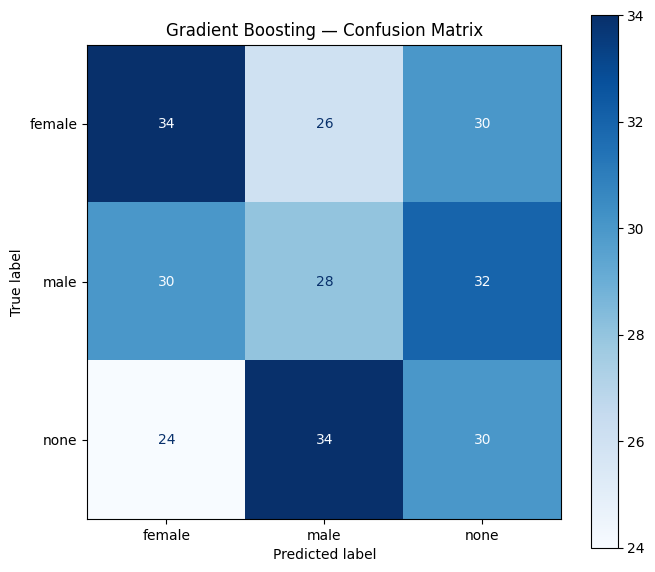

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_reduced,
    gb_reduced_predictions
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Gradient Boosting — Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 47 — Final Model Summary

final_model_summary = pd.DataFrame([
    {
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "F1": baseline_f1
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1": logistic_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": gb_accuracy,
        "Precision": gb_precision,
        "Recall": gb_recall,
        "F1": gb_f1
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_accuracy,
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1": xgb_f1
    },
    {
        "Model": "Gradient Boosting (Reduced)",
        "Accuracy": gb_reduced_accuracy,
        "Precision": gb_reduced_precision,
        "Recall": gb_reduced_recall,
        "F1": gb_reduced_f1
    }
])

final_model_summary = (
    final_model_summary
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    final_model_summary.round(4)
)

print("\nBest model:")
print(
    final_model_summary.iloc[0]["Model"]
)

,Model,Accuracy,Precision,Recall,F1
0,Gradient Boosting (Reduced),0.3433,0.3437,0.3433,0.3434
1,Logistic Regression,0.3358,0.3369,0.3358,0.3363
2,Gradient Boosting,0.3321,0.3317,0.3321,0.3319
3,Random Forest,0.3321,0.3326,0.3321,0.3317
4,XGBoost,0.3060,0.3053,0.3060,0.3049
5,Baseline,0.3358,0.1128,0.3358,0.1688



Best model:
Gradient Boosting (Reduced)


In [ ]:

import joblib
import os

# Save the complete pipeline
model_path = "final_gender_classifier.pkl"

joblib.dump(
    gb_reduced,
    model_path
)

print("Final model saved successfully.")
print("File:", model_path)
print("File size:", round(os.path.getsize(model_path) / 1024, 2), "KB")

Final model saved successfully.
File: final_gender_classifier.pkl
File size: 759.83 KB


In [ ]:
import joblib

loaded_gender_model = joblib.load(
    "final_gender_classifier.pkl"
)

print("Saved gender model loaded successfully.")
print(type(loaded_gender_model))

Saved gender model loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [ ]:

def predict_gender(
    company,
    age,
    flight_count,
    total_flight_spend,
    average_flight_price,
    average_flight_distance,
    total_flight_distance,
    unique_destinations,
    unique_flight_types,
    unique_agencies,
    hotel_booking_count,
    total_hotel_spend,
    average_hotel_spend,
    average_hotel_price,
    average_stay_days,
    total_stay_days,
    unique_hotels
):

    new_user = pd.DataFrame({
        "company": [company],
        "age": [age],
        "flight_count": [flight_count],
        "total_flight_spend": [total_flight_spend],
        "average_flight_price": [average_flight_price],
        "average_flight_distance": [average_flight_distance],
        "total_flight_distance": [total_flight_distance],
        "unique_destinations": [unique_destinations],
        "unique_flight_types": [unique_flight_types],
        "unique_agencies": [unique_agencies],
        "hotel_booking_count": [hotel_booking_count],
        "total_hotel_spend": [total_hotel_spend],
        "average_hotel_spend": [average_hotel_spend],
        "average_hotel_price": [average_hotel_price],
        "average_stay_days": [average_stay_days],
        "total_stay_days": [total_stay_days],
        "unique_hotels": [unique_hotels]
    })

    prediction = loaded_gender_model.predict(
        new_user
    )[0]

    probability = loaded_gender_model.predict_proba(
        new_user
    )[0]

    predicted_gender = label_encoder.inverse_transform(
        [prediction]
    )[0]

    probability_table = pd.DataFrame({
        "Gender": label_encoder.classes_,
        "Probability": probability
    })

    probability_table["Probability"] = (
        probability_table["Probability"] * 100
    ).round(2)

    return predicted_gender, probability_table

In [ ]:

predicted_gender, probability_table = predict_gender(
    company="4You",
    age=35,
    flight_count=200,
    total_flight_spend=190000,
    average_flight_price=950,
    average_flight_distance=540,
    total_flight_distance=108000,
    unique_destinations=9,
    unique_flight_types=3,
    unique_agencies=3,
    hotel_booking_count=30,
    total_hotel_spend=16000,
    average_hotel_spend=530,
    average_hotel_price=210,
    average_stay_days=2.5,
    total_stay_days=75,
    unique_hotels=8
)

print("Predicted gender:", predicted_gender)

print("\nPrediction probabilities:")
display(probability_table)

Predicted gender: none

Prediction probabilities:


,Gender,Probability
0,female,35.22
1,male,23.27
2,none,41.51


In [ ]:

# Copy the user-level dataset
user_predictions = user_ml_data.copy()

# Generate predictions using the saved model
user_predictions["predicted_gender_encoded"] = (
    loaded_gender_model.predict(
        user_predictions[classification_features_reduced]
    )
)

# Convert encoded predictions back to labels
user_predictions["predicted_gender"] = (
    label_encoder.inverse_transform(
        user_predictions["predicted_gender_encoded"]
    )
)

print("Batch prediction completed.")

print("\nDataset shape:")
print(user_predictions.shape)

print("\nPredicted gender distribution:")
print(
    user_predictions["predicted_gender"]
    .value_counts()
)

print("\nFirst 10 predictions:")

display(
    user_predictions[
        [
            "code",
            "company",
            "age",
            "gender",
            "predicted_gender"
        ]
    ].head(10)
)

Batch prediction completed.

Dataset shape:
(1340, 27)

Predicted gender distribution:
predicted_gender
female    474
male      452
none      414
Name: count, dtype: int64

First 10 predictions:


,code,company,age,gender,predicted_gender
0,0,4You,21,male,female
1,1,4You,37,male,male
2,2,4You,48,female,female
3,3,4You,23,female,female
4,4,4You,44,female,female
5,5,4You,47,none,male
6,6,4You,46,male,female
7,7,4You,21,female,female
8,8,4You,41,none,none
9,9,4You,35,none,none


In [ ]:

# Overall accuracy on all users
full_accuracy = accuracy_score(
    user_predictions["gender"],
    user_predictions["predicted_gender"]
)

print("Full Dataset Prediction Results")
print("=" * 45)

print(
    f"Accuracy: {full_accuracy:.4f}"
)

print(
    f"Accuracy: {full_accuracy * 100:.2f}%"
)


# Actual vs predicted counts
comparison_table = pd.crosstab(
    user_predictions["gender"],
    user_predictions["predicted_gender"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

print("\nActual vs Predicted:")
display(comparison_table)


# Correct / incorrect predictions
user_predictions["prediction_correct"] = (
    user_predictions["gender"]
    ==
    user_predictions["predicted_gender"]
)

print("\nCorrect predictions:",
      user_predictions["prediction_correct"].sum())

print("Incorrect predictions:",
      (~user_predictions["prediction_correct"]).sum())

Full Dataset Prediction Results
Accuracy: 0.7567
Accuracy: 75.67%

Actual vs Predicted:


Predicted,female,male,none
Actual,,,
female,350,49,49
male,59,346,47
none,65,57,318



Correct predictions: 1014
Incorrect predictions: 326


In [ ]:

output_columns = [
    "code",
    "company",
    "name",
    "gender",
    "age",
    "predicted_gender",
    "prediction_correct"
]

final_predictions = user_predictions[
    output_columns
].copy()

output_file = "final_gender_predictions.csv"

final_predictions.to_csv(
    output_file,
    index=False
)

print("Prediction dataset exported successfully.")
print("File:", output_file)
print("Rows:", len(final_predictions))

print("\nFirst 10 rows:")
display(
    final_predictions.head(10)
)

Prediction dataset exported successfully.
File: final_gender_predictions.csv
Rows: 1340

First 10 rows:


,code,company,name,gender,age,predicted_gender,prediction_correct
0,0,4You,Roy Braun,male,21,female,False
1,1,4You,Joseph Holsten,male,37,male,True
2,2,4You,Wilma Mcinnis,female,48,female,True
3,3,4You,Paula Daniel,female,23,female,True
4,4,4You,Patricia Carson,female,44,female,True
5,5,4You,Trina Thomas,none,47,male,False
6,6,4You,Jesse Decelle,male,46,female,False
7,7,4You,Gregoria Gil,female,21,female,True
8,8,4You,Jack Sabo,none,41,none,True
9,9,4You,Debbie Helms,none,35,none,True


In [ ]:

print("=" * 60)
print("FINAL GENDER CLASSIFICATION PROJECT SUMMARY")
print("=" * 60)

print("\nDataset")
print("-" * 30)
print("Total users              :", len(user_ml_data))
print("Final features           :", len(classification_features_reduced))
print("Number of classes        :", len(label_encoder.classes_))
print("Classes                  :", list(label_encoder.classes_))

print("\nTrain/Test Split")
print("-" * 30)
print("Training samples         :", len(X_train_reduced))
print("Testing samples          :", len(X_test_reduced))

print("\nBest Model")
print("-" * 30)
print("Model                    : Gradient Boosting")
print("Features                 : Reduced (17)")
print(f"Test Accuracy            : {gb_reduced_accuracy:.4f}")
print(f"Test Precision           : {gb_reduced_precision:.4f}")
print(f"Test Recall              : {gb_reduced_recall:.4f}")
print(f"Test F1 Score            : {gb_reduced_f1:.4f}")
print(f"5-Fold CV Accuracy       : {cv_scores.mean():.4f}")
print(f"5-Fold CV Std            : {cv_scores.std():.4f}")

print("\nStatistical Analysis")
print("-" * 30)
print("Significant numerical feature:")
print("average_stay_days (p = 0.019340)")
print("Company × Gender p-value: 0.374978")

print("\nModel File")
print("-" * 30)
print("final_gender_classifier.pkl")

print("\nPrediction File")
print("-" * 30)
print("final_gender_predictions.csv")

print("\nFinal Conclusion")
print("-" * 30)
print(
    "The available travel behavioral features provide "
    "limited predictive information about gender."
)
print(
    "Model performance is close to the expected chance level "
    "for three balanced classes."
)

print("\n" + "=" * 60)

FINAL GENDER CLASSIFICATION PROJECT SUMMARY

Dataset
------------------------------
Total users              : 1340
Final features           : 17
Number of classes        : 3
Classes                  : ['female', 'male', 'none']

Train/Test Split
------------------------------
Training samples         : 1072
Testing samples          : 268

Best Model
------------------------------
Model                    : Gradient Boosting
Features                 : Reduced (17)
Test Accuracy            : 0.3433
Test Precision           : 0.3437
Test Recall              : 0.3433
Test F1 Score            : 0.3434
5-Fold CV Accuracy       : 0.3351
5-Fold CV Std            : 0.0250

Statistical Analysis
------------------------------
Significant numerical feature:
average_stay_days (p = 0.019340)
Company × Gender p-value: 0.374978

Model File
------------------------------
final_gender_classifier.pkl

Prediction File
------------------------------
final_gender_predictions.csv

Final Conclusion
---------

In [ ]:
import os

model_file = "final_gender_classifier.pkl"
prediction_file = "final_gender_predictions.csv"

print("Model exists:", os.path.exists(model_file))
print("Prediction CSV exists:", os.path.exists(prediction_file))

if os.path.exists(model_file):
    print(
        "Model size:",
        round(os.path.getsize(model_file) / 1024, 2),
        "KB"
    )

if os.path.exists(prediction_file):
    print(
        "Prediction CSV size:",
        round(os.path.getsize(prediction_file) / 1024, 2),
        "KB"
    )

Model exists: True
Prediction CSV exists: True
Model size: 759.83 KB
Prediction CSV size: 63.57 KB


In [ ]:
# Cell 58 — Production Prediction Function

import pandas as pd
import joblib

# Load model from disk
model = joblib.load("final_gender_classifier.pkl")


def predict_user_gender(user_data):
    """
    Predict gender from user behavioral features.

    Parameters
    ----------
    user_data : pandas.DataFrame
        DataFrame containing the 17 model features.

    Returns
    -------
    pandas.DataFrame
        Prediction and class probabilities.
    """

    required_features = [
        "company",
        "age",
        "flight_count",
        "total_flight_spend",
        "average_flight_price",
        "average_flight_distance",
        "total_flight_distance",
        "unique_destinations",
        "unique_flight_types",
        "unique_agencies",
        "hotel_booking_count",
        "total_hotel_spend",
        "average_hotel_spend",
        "average_hotel_price",
        "average_stay_days",
        "total_stay_days",
        "unique_hotels"
    ]

    # Check required columns
    missing_features = [
        feature
        for feature in required_features
        if feature not in user_data.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing features: {missing_features}"
        )

    # Keep exact model feature order
    X = user_data[required_features].copy()

    # Prediction
    predictions = model.predict(X)

    probabilities = model.predict_proba(X)

    # Convert encoded prediction to original label
    predicted_gender = label_encoder.inverse_transform(
        predictions
    )

    result = X.copy()

    result["predicted_gender"] = predicted_gender

    result["female_probability"] = (
        probabilities[:, 0] * 100
    ).round(2)

    result["male_probability"] = (
        probabilities[:, 1] * 100
    ).round(2)

    result["none_probability"] = (
        probabilities[:, 2] * 100
    ).round(2)

    return result


print("Production prediction function created successfully.")

Production prediction function created successfully.


In [ ]:

# Use the 17 model features from the existing dataset
test_users = user_ml_data[
    classification_features_reduced
].copy()

# Run production prediction function
production_predictions = predict_user_gender(
    test_users
)

print("Production prediction test completed.")

print("\nOutput shape:")
print(production_predictions.shape)

print("\nPredicted gender distribution:")
print(
    production_predictions["predicted_gender"]
    .value_counts()
)

print("\nFirst 5 predictions:")
display(
    production_predictions[
        [
            "company",
            "age",
            "predicted_gender",
            "female_probability",
            "male_probability",
            "none_probability"
        ]
    ].head()
)

Production prediction test completed.

Output shape:
(1340, 21)

Predicted gender distribution:
predicted_gender
female    474
male      452
none      414
Name: count, dtype: int64

First 5 predictions:


,company,age,predicted_gender,female_probability,male_probability,none_probability
0,4You,21,female,40.94,38.20,20.86
1,4You,37,male,15.00,59.50,25.50
2,4You,48,female,55.54,28.03,16.43
3,4You,23,female,73.87,6.31,19.82
4,4You,44,female,62.28,18.87,18.85
